<h1 style="
    font-size: 72px;
    color: #6A8D73 ;
    font-family: 'Impact', sans-serif;
    font-weight: 500;
">
    🚚🗑️💨 Trash Haulers
</h1>

<h1 style="
    font-size: 24px;
    color: #B87C4F;
    font-family: 'Montserrat', sans-serif;
    font-weight: 600;
">
Imports Incoming
</h1>

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

<h1 style="
    font-size: 24px;
    color: #B87C4F;
    font-family: 'Montserrat', sans-serif;
    font-weight: 600;
">
Inspect Data
</h1>
and remove some leading/trailing whitespace in column titles (I'm looking at you, 'Request ')

In [2]:
#import csv
trash = pd.read_csv('./trash_hauler_report.csv')

#remove whitespace from column title beginnings/ends
trash.columns = trash.columns.str.strip()

#let's have a look-see
trash.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/01/17,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207.0,RED RIVER,3205,2.0,1.727970e+06,686779.478089
1,25274,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1.721259e+06,685444.799565
2,25276,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1.707027e+06,659887.471571
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1.735692e+06,685027.245923
4,25312,11/01/17,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1.710186e+06,664205.101066


In [3]:
trash.shape

(20226, 11)

<h1 style="
    font-size: 24px;
    color: #B87C4F;
    font-family: 'Montserrat', sans-serif;
    font-weight: 600;
">
Complaint Types
</h1>

In [4]:
print("All complaint categories:\n")
print(trash['Request'].value_counts().to_string())

All complaint categories:

Request
Trash - Curbside/Alley Missed Pickup    15028
Trash - Backdoor                         2629
Trash Collection Complaint               2312
Damage to Property                        257


<h1 style="
    font-size: 24px;
    color: #B87C4F;
    font-family: 'Montserrat', sans-serif;
    font-weight: 600;
">
Missed Trash
</h1>

C:\Users\BolognaColonel\AppData\Local\Temp\ipykernel_15264\2001851219.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  missed_pickups = trash[(trash['Description'].str.contains(r"(.*miss.*|.*skip.*|.*(n[o']t|never).*(pick.*up|collect|empt).*)|(.*(pick.*up|collect|empt).*(except).*)", na=False, regex=True)) |


Total missed pickups: 17497
Percentage of all requests: 86.51%


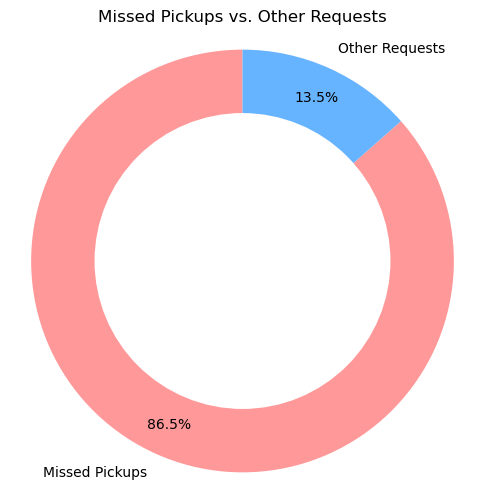

In [5]:
# Filter rows for terms related to missed pickups
missed_pickups = trash[(trash['Description'].str.contains(r"(.*miss.*|.*skip.*|.*(n[o']t|never).*(pick.*up|collect|empt).*)|(.*(pick.*up|collect|empt).*(except).*)", na=False, regex=True)) |
(trash['Request'] == 'Trash - Curbside/Alley Missed Pickup')].reset_index(drop=True)

#combine METRO and Metro
missed_pickups['Trash Hauler'] = missed_pickups['Trash Hauler'].str.strip().str.upper()

#missed pickup count and ratio to total
print(f"Total missed pickups: {len(missed_pickups)}")
print(f"Percentage of all requests: {len(missed_pickups)/len(trash)*100:.2f}%")

total_requests = len(trash)
missed = len(missed_pickups)
not_missed = total_requests - missed

# data for donut chart
sizes = [missed, not_missed]
labels = ['Missed Pickups', 'Other Requests']
colors = ['#ff9999', '#66b3ff']  # customize as you like

# create donut chart
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, pctdistance=0.85)

# draw a circle in the center to make it a donut lol, so funny you can do this
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# equal aspect ratio ensures the pie is drawn as a circle
plt.axis('equal')
plt.title('Missed Pickups vs. Other Requests')
plt.show()

# display the first 5 rows
# missed_pickups.head(
# )

<h1 style="
    font-size: 24px;
    color: #B87C4F;
    font-family: 'Montserrat', sans-serif;
    font-weight: 600;
">
... by Council District
</h1>

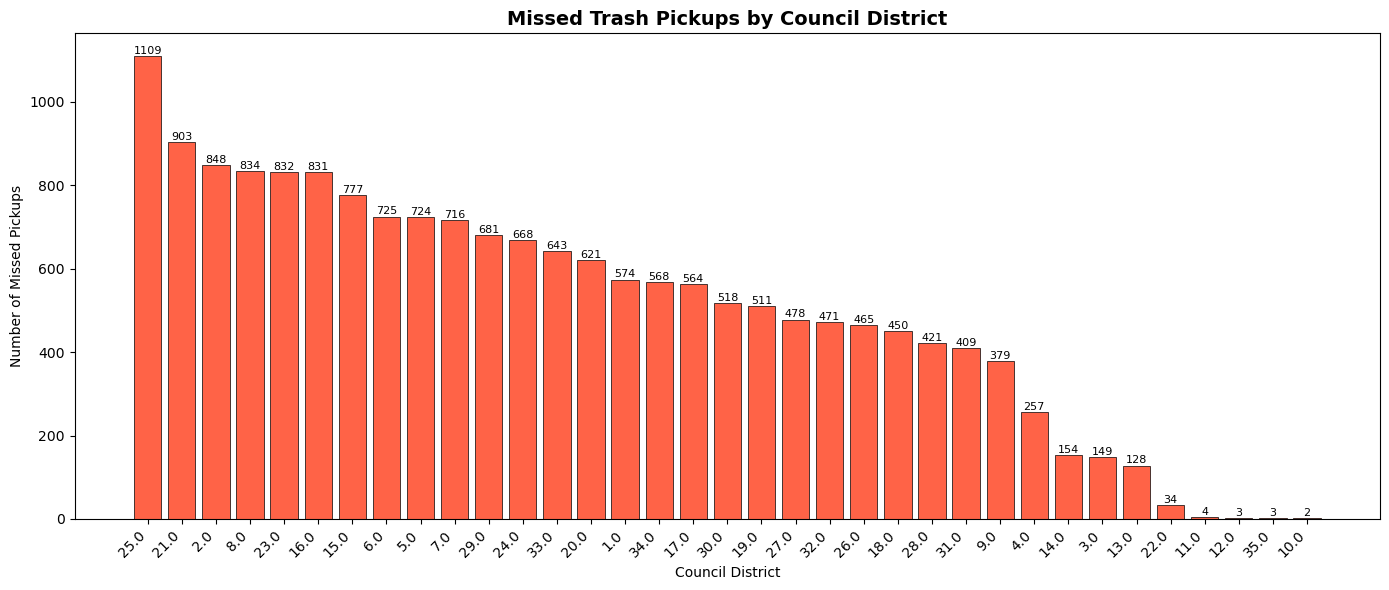

In [6]:
# count by Council District
district_counts = missed_pickups['Council District'].value_counts()

# plot thickens
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(district_counts.index.astype(str), district_counts.values, color='tomato', edgecolor='black', linewidth=0.5)

# labels
for bar, val in zip(bars, district_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, str(val),
            ha='center', va='bottom', fontsize=8)

ax.set_title('Missed Trash Pickups by Council District', fontsize=14, fontweight='bold')
ax.set_xlabel('Council District')
ax.set_ylabel('Number of Missed Pickups')
ax.set_xticks(range(len(district_counts)))
ax.set_xticklabels(district_counts.index.astype(str), rotation=45, ha='right')
plt.tight_layout()
plt.show()

<h1 style="
    font-size: 24px;
    color: #B87C4F;
    font-family: 'Montserrat', sans-serif;
    font-weight: 600;
">
Total Damages 🎯💸
</h1>

In [7]:
missed_pickups_sorted = missed_pickups.sort_values(['Incident Address', 'Date Opened'])
missed_pickups_sorted['pickup_rank'] = missed_pickups_sorted.groupby('Incident Address').cumcount() + 1
fines = []
for rank in missed_pickups_sorted['pickup_rank']:
    if rank > 1:
        fines.append(200)
    else:
        fines.append(0)
missed_pickups_sorted['fine'] = fines

# missed_pickups_sorted.head(100)
print(f"Total Damages: ${missed_pickups_sorted['fine'].sum():,.2f}")

Total Damages: $961,400.00


<h1 style="
    font-size: 24px;
    color: #B87C4F;
    font-family: 'Montserrat', sans-serif;
    font-weight: 600;
">
... by ZIP Code
</h1>

In [8]:
zip_summary = missed_pickups_sorted.groupby('Zip Code').agg(
    total_missed=('fine', 'count'),
    total_fines=('fine', 'sum')
).reset_index().sort_values('total_fines', ascending=False)

print(zip_summary)

    Zip Code  total_missed  total_fines
0    37013.0          2097       116200
16   37211.0          1970       107600
20   37215.0          1271        80400
10   37205.0          1177        75600
4    37115.0          1091        72600
14   37209.0          1198        64800
12   37207.0          1078        57800
13   37208.0           904        49400
23   37218.0           854        48400
11   37206.0          1069        43800
22   37217.0           729        40000
19   37214.0           854        37400
21   37216.0           708        30800
9    37204.0           557        30600
17   37212.0           519        25400
15   37210.0           459        24800
8    37203.0           352        24200
25   37220.0           234        11000
1    37027.0           136         7000
6    37189.0            57         3800
26   37221.0            46         3200
24   37219.0            31         2800
7    37201.0            30         1800
3    37086.0             3          200


<h1 style="
    font-size: 36px;
    color: #B87C4F;
    font-family: 'Montserrat', sans-serif;
    font-weight: 600;
">
Fines Per Hauler 🚛💸
</h1>

Trash Hauler
RED RIVER    690200
METRO        157000
WASTE IND     55600
Name: fine, dtype: int64


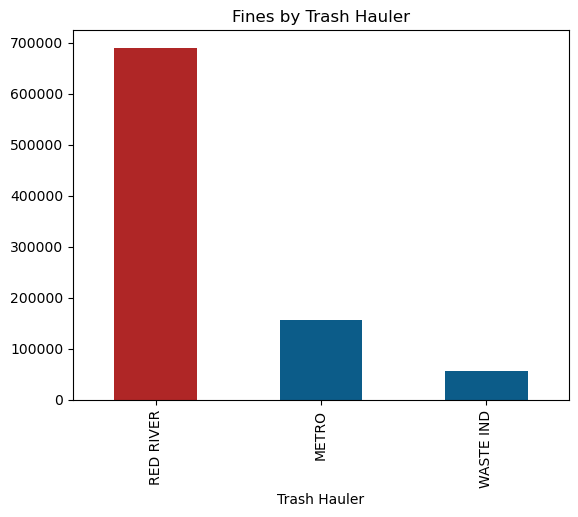

In [9]:
hauler_fines = missed_pickups_sorted.groupby('Trash Hauler')['fine'].sum().sort_values(ascending=False)

#have a look
print(hauler_fines)

#plot it
colors = ['#af2626' if h == 'RED RIVER' else '#0C5C89' for h in hauler_fines.index]
hauler_fines.plot(kind='bar', title='Fines by Trash Hauler', color=colors)
plt.show()

In [10]:
# missed_pickups_sorted['hauler_type'] = missed_pickups_sorted['Trash Hauler'].apply(
#     lambda x: 'Red River' if str(x).upper() == 'RED RIVER' else 'Other Haulers'
# )

# hauler_comparison = missed_pickups_sorted.groupby('hauler_type').agg(
#     total_missed=('fine', 'count'),
#     total_fines=('fine', 'sum')
# ).reset_index()

# fig, ax = plt.subplots(figsize=(7, 5))
# ax.bar(['Other Haulers', 'Red River'], hauler_comparison['total_missed'], color=['#3498db', '#e74c3c'], width=0.5)
# ax.set_title('Missed Pickups: Red River vs Other Haulers')
# ax.set_ylabel('Total Missed Pickups')
# plt.show()

<h1 style="
    font-size: 36px;
    color: #B87C4F;
    font-family: 'Montserrat', sans-serif;
    font-weight: 600;
">
Missed Pickups by Route
</h1>

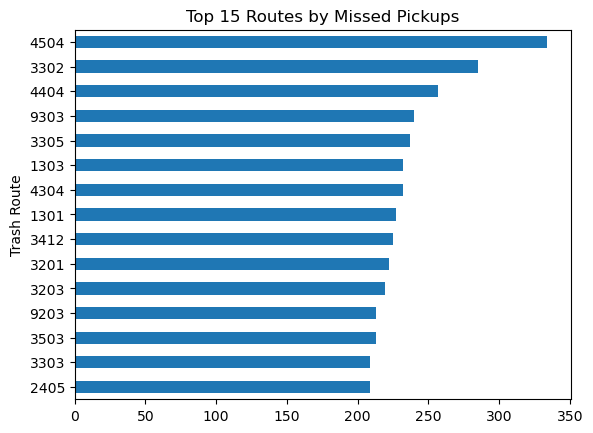

In [11]:
route_summary = missed_pickups_sorted.groupby('Trash Route')['fine'].count().sort_values(ascending=False)
ax = route_summary.head(15).plot(kind='barh', title='Top 15 Routes by Missed Pickups')
ax.invert_yaxis()
plt.show()

<h1 style="
    font-size: 36px;
    color: #B87C4F;
    font-family: 'Montserrat', sans-serif;
    font-weight: 600;
">
Whose Routes Are These?
</h1>

In [12]:
routes = ['4504', '3302','4404', '9303', '3305', '1303', '4304', '1301', '3412', '3201', '3203', '9203', '3503', '3303', '2405']
print(missed_pickups_sorted[missed_pickups_sorted['Trash Route'].isin(routes)].groupby(['Trash Route', 'Trash Hauler'])['fine'].count().sort_values(ascending=False))

Trash Route  Trash Hauler
4504         RED RIVER       334
3302         RED RIVER       285
4404         RED RIVER       257
9303         METRO           240
3305         RED RIVER       235
1303         RED RIVER       232
4304         RED RIVER       232
1301         RED RIVER       227
3201         RED RIVER       222
3203         RED RIVER       219
3412         RED RIVER       219
9203         METRO           213
3503         RED RIVER       211
2405         RED RIVER       209
3303         RED RIVER       209
3305         METRO             1
Name: fine, dtype: int64


<h1 style="
    font-size: 36px;
    color: #B87C4F;
    font-family: 'Montserrat', sans-serif;
    font-weight: 600;
">
Problem Addresses
</h1>

In [13]:
print(missed_pickups_sorted.groupby(['Incident Address', 'Trash Route']).size().sort_values(ascending=False).head(20))

Incident Address                                            Trash Route
12546 Old Hickory Blvd, Nashville, TN 37013, United States  4510           19
5135 Hickory Hollow Pkwy                                    4504           17
802 Crescent Rd, Nashville, TN 37205, United States         2303           17
3710 N NATCHEZ CT                                           4302           17
1816 Jo Johnston Ave, Nashville, TN 37203, United States    9208           16
6007 Obrien Ave, Nashville, TN 37209, United States         4201           16
607 Estes Rd, Nashville, TN 37215, United States            2303           15
617 kinsey blvd                                             3314           13
320 Old Hickory Blvd, Nashville, TN 37221, United States    1303           12
1537 Harding Pl, Nashville, TN 37215, United States         3303           11
14881 Old Hickory Blvd, Nashville, TN 37013, United States  4403           11
111 Barton Ln, Nashville, TN 37214, United States           1501      